# Three-Tier HP Prediction Model

## Model Architecture:
- **Low-CR Model (CR ≤ 1)**: Optimized for very low CR creatures
- **Mid-CR Model (1 < CR ≤ 12)**: Standard model for most creatures
- **High-CR Model (CR > 12)**: Handles legendary/epic creatures

Each model uses the same three-phase approach but with different constraints tuned for their CR range.

In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Imports successful")

✅ Imports successful


## Load Data

In [2]:
# Load monster dataset (from JSON - has complete action data)
df = pd.read_csv('../data/dnd5e_monsters_from_json.csv')
print(f"📊 Loaded {len(df)} monsters from JSON-based dataset")

# Load Lazy 5e baseline stats
lazy_5e = pd.read_csv('../data/lazy_5e_monster_stats_by_cr.csv')
print(f"📊 Loaded {len(lazy_5e)} CR baselines from Lazy 5e")

print("\n🔍 Lazy 5e Baseline Stats Preview:")
display(lazy_5e.head(10))

📊 Loaded 382 monsters from JSON-based dataset
📊 Loaded 34 CR baselines from Lazy 5e

🔍 Lazy 5e Baseline Stats Preview:


,CR,Eqv_Char_Lvl,AC_DC,HP,Attack_Bonus,Damage_Round,Num_Attacks,Damage_Attack,Example_Monster
0,0,< 1,10,3 (2-4),2,2,1,2 (1d4),"Commoner, rat, spider"
1,1/8,< 1,11,9 (7-11),3,3,1,4 (1d6 + 1),"Bandit, cultist, giant rat"
2,1/4,1,11,13 (10-16),3,5,1,5 (1d6 + 2),"Acolyte, skeleton, wolf"
3,1/2,2,12,22 (17-28),4,8,2,4 (1d4 + 2),"Black bear, scout, shadow"
4,1,3,12,33 (25-41),5,12,2,6 (1d8 + 2),"Dire wolf, specter, spy"
5,2,5,13,45 (34-56),5,17,2,9 (2d6 + 2),"Ghast, ogre, priest"
6,3,7,13,65 (49-81),5,23,2,12 (2d8 + 3),"Knight, mummy, werewolf"
7,4,9,14,84 (64-106),6,28,2,14 (3d8 + 1),"Ettin, ghost"
8,5,10,15,95 (71-119),7,35,3,12 (3d6 + 2),"Elemental, gladiator, vampire spawn"
9,6,11,15,112 (84-140),7,41,3,14 (3d6 + 4),"Mage, medusa, wyvern"


## Parse CR and Create Baseline Lookup Functions

In [3]:
# Parse CR from string to numeric
def parse_cr(cr_str):
    if pd.isna(cr_str):
        return 0
    cr_str = str(cr_str).strip()
    if '/' in cr_str:
        num, denom = cr_str.split('/')
        return float(num) / float(denom)
    try:
        return float(cr_str)
    except:
        return 0

# Convert Lazy 5e CR to numeric
lazy_5e['cr_numeric'] = lazy_5e['CR'].apply(parse_cr)

# Parse HP from Lazy 5e (extract average from "65 (49-81)" format)
def parse_hp_avg(hp_str):
    if pd.isna(hp_str):
        return 0
    match = re.match(r'(\d+)', str(hp_str))
    return int(match.group(1)) if match else 0

lazy_5e['hp_baseline'] = lazy_5e['HP'].apply(parse_hp_avg)

# Adjust HP baselines: +50% for CR <= 1, +20% for CR >= 2
def adjust_hp_baseline(row):
    if row['cr_numeric'] <= 1.0:
        return row['hp_baseline'] * 1.5
    else:
        return row['hp_baseline'] * 1.2

lazy_5e['hp_baseline'] = lazy_5e.apply(adjust_hp_baseline, axis=1)
print("✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2")

# Parse Attack Bonus - handles both numeric (3) and "+3" format
def parse_bonus(bonus_str):
    if pd.isna(bonus_str):
        return 0
    bonus_str = str(bonus_str).strip()
    # Try to match "+3" format first
    match = re.search(r'\+(\d+)', bonus_str)
    if match:
        return int(match.group(1))
    # Try direct numeric format
    try:
        return int(bonus_str)
    except:
        return 0

lazy_5e['attack_baseline'] = lazy_5e['Attack_Bonus'].apply(parse_bonus)
lazy_5e['ac_baseline'] = lazy_5e['AC_DC']
lazy_5e['dpr_baseline'] = lazy_5e['Damage_Round']

print("✅ Parsed Lazy 5e baselines")
print("\n📊 Baseline Stats by CR:")
display(lazy_5e[['cr_numeric', 'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline']].head(15))

✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2
✅ Parsed Lazy 5e baselines

📊 Baseline Stats by CR:


,cr_numeric,hp_baseline,ac_baseline,attack_baseline,dpr_baseline
0,0.000,4.5,10,2,2
1,0.125,13.5,11,3,3
2,0.250,19.5,11,3,5
3,0.500,33.0,12,4,8
4,1.000,49.5,12,5,12
5,2.000,54.0,13,5,17
6,3.000,78.0,13,5,23
7,4.000,100.8,14,6,28
8,5.000,114.0,15,7,35
9,6.000,134.4,15,7,41


In [4]:
# Create interpolation functions for baselines
cr_values = lazy_5e['cr_numeric'].values
hp_baseline_interp = interp1d(cr_values, lazy_5e['hp_baseline'].values, 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
ac_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
                               kind='linear', bounds_error=False, fill_value='extrapolate')
attack_baseline_interp = interp1d(cr_values, lazy_5e['attack_baseline'].values,
                                   kind='linear', bounds_error=False, fill_value='extrapolate')
dpr_baseline_interp = interp1d(cr_values, lazy_5e['dpr_baseline'].values,
                                kind='linear', bounds_error=False, fill_value='extrapolate')
# DC baseline uses same values as AC (from AC_DC column)
dc_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
                               kind='linear', bounds_error=False, fill_value='extrapolate')

def get_baseline_hp(cr):
    return float(hp_baseline_interp(cr))

def get_baseline_ac(cr):
    return float(ac_baseline_interp(cr))

def get_baseline_attack(cr):
    return float(attack_baseline_interp(cr))

def get_baseline_dpr(cr):
    return float(dpr_baseline_interp(cr))

def get_baseline_dc(cr):
    return float(dc_baseline_interp(cr))

print("✅ Created baseline interpolation functions")

✅ Created baseline interpolation functions


## Feature Engineering (Common to All Models)

In [5]:
print("⚙️  FEATURE ENGINEERING")
print("="* 60)

# Parse CR
df['cr_numeric'] = df['Challenge_Rating'].apply(parse_cr)

# Parse AC
def parse_ac(ac_str):
    if pd.isna(ac_str):
        return 10
    match = re.search(r'\d+', str(ac_str))
    return int(match.group()) if match else 10

df['ac_value'] = df['AC'].apply(parse_ac)

# Parse speeds
def parse_speed(speed_str, speed_type):
    if pd.isna(speed_str):
        return 0
    speed_str = str(speed_str).lower()
    if speed_type == 'ground':
        match = re.search(r'^(\d+)\s*ft', speed_str)
        return int(match.group(1)) if match else 0
    else:
        pattern = rf'{speed_type}\s+(\d+)\s*ft'
        match = re.search(pattern, speed_str)
        return int(match.group(1)) if match else 0

df['speed_ground'] = df['Speed'].apply(lambda x: parse_speed(x, 'ground'))
df['speed_fly'] = df['Speed'].apply(lambda x: parse_speed(x, 'fly'))
df['speed_swim'] = df['Speed'].apply(lambda x: parse_speed(x, 'swim'))
df['speed_burrow'] = df['Speed'].apply(lambda x: parse_speed(x, 'burrow'))
df['speed_climb'] = df['Speed'].apply(lambda x: parse_speed(x, 'climb'))

df['max_speed'] = df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']].max(axis=1)
df['movement_types_count'] = (df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']] > 0).sum(axis=1)
df['has_flying'] = (df['speed_fly'] > 0).astype(int)

# Parse proficiencies
def count_proficiencies(prof_str):
    if pd.isna(prof_str) or str(prof_str).strip() == '':
        return 0
    return len([x.strip() for x in str(prof_str).split(',') if x.strip()])

df['save_proficiency_count'] = df['Saving_Throws'].apply(count_proficiencies)
df['skill_proficiency_count'] = df['Skills'].apply(count_proficiencies)
df['resistance_count'] = df['Resistances'].apply(count_proficiencies)
df['immunity_count'] = df['Immunities'].apply(count_proficiencies)
df['vulnerability_count'] = df['Vulnerabilities'].apply(count_proficiencies)
df['condition_immunity_count'] = df['Condition_Immunities'].apply(count_proficiencies)

print("✅ Basic features parsed")

⚙️  FEATURE ENGINEERING
✅ Basic features parsed


In [6]:
# Parse senses
def has_sense(sense_str, sense_type):
    if pd.isna(sense_str):
        return 0
    return 1 if sense_type in str(sense_str).lower() else 0

def parse_sense_range(sense_str, sense_type):
    if pd.isna(sense_str):
        return 0
    pattern = rf'{sense_type}\s+(\d+)\s*ft'
    match = re.search(pattern, str(sense_str).lower())
    return int(match.group(1)) if match else 0

df['has_darkvision'] = df['Senses'].apply(lambda x: has_sense(x, 'darkvision'))
df['darkvision_range'] = df['Senses'].apply(lambda x: parse_sense_range(x, 'darkvision'))
df['has_blindsight'] = df['Senses'].apply(lambda x: has_sense(x, 'blindsight'))
df['has_truesight'] = df['Senses'].apply(lambda x: has_sense(x, 'truesight'))
df['has_tremorsense'] = df['Senses'].apply(lambda x: has_sense(x, 'tremorsense'))

def parse_passive_perception(sense_str):
    if pd.isna(sense_str):
        return 10
    match = re.search(r'passive\s+perception\s+(\d+)', str(sense_str).lower())
    return int(match.group(1)) if match else 10

df['passive_perception'] = df['Senses'].apply(parse_passive_perception)

print("✅ Senses parsed")

✅ Senses parsed


In [7]:
# Parse abilities from text
def count_abilities(text_str):
    if pd.isna(text_str) or str(text_str).strip() == '':
        return 0
    text = str(text_str).strip()
    entries = [x for x in re.split(r'\n+|\*\s+', text) if x.strip()]
    return len(entries)

df['trait_count'] = df['Traits'].apply(count_abilities)
df['action_count'] = df['Actions'].apply(count_abilities)
df['reaction_count'] = df['Reactions'].apply(count_abilities)
df['bonus_action_count'] = df['Bonus_Actions'].apply(count_abilities)

# Legendary actions
def parse_legendary_actions(leg_str):
    if pd.isna(leg_str) or str(leg_str).strip() == '':
        return 0, 0, 0
    text = str(leg_str).lower()
    has_leg = 1
    count_match = re.search(r'(\d+)\s+legendary\s+actions?', text)
    per_round = int(count_match.group(1)) if count_match else 3
    action_count = len([x for x in re.split(r'\n+|\*\s+', text) if x.strip() and 'can take' not in x.lower()])
    return has_leg, action_count, per_round

df[['has_legendary_actions', 'legendary_action_count', 'legendary_actions_per_round']] = df['Legendary_Actions'].apply(
    lambda x: pd.Series(parse_legendary_actions(x))
)

df['total_ability_count'] = df['trait_count'] + df['action_count'] + df['reaction_count'] + df['legendary_action_count']

print("✅ Ability counts parsed")

✅ Ability counts parsed


In [8]:
# Parse specific abilities
combined_abilities = (df['Traits'].fillna('') + ' ' + df['Actions'].fillna('') + ' ' +
                     df['Reactions'].fillna('') + ' ' + df['Legendary_Actions'].fillna(''))

# Combat metrics - parse from JSON action structures
def parse_attack_bonus(actions_str):
    """Parse attack bonus from JSON-formatted actions"""
    if pd.isna(actions_str):
        return 0
    try:
        actions = json.loads(actions_str)
        bonuses = []
        for action in actions:
            if isinstance(action, dict) and 'Hit Bonus' in action:
                try:
                    bonuses.append(int(action['Hit Bonus']))
                except (ValueError, TypeError):
                    pass
        return max(bonuses) if bonuses else 0
    except (json.JSONDecodeError, TypeError):
        return 0

def parse_save_dc(text_str):
    """Parse save DC from text (traits, actions, reactions, legendary actions)"""
    if pd.isna(text_str):
        return 0
    matches = re.findall(r'dc\s+(\d+)', str(text_str).lower())
    return max([int(m) for m in matches]) if matches else 0

df['highest_attack_bonus'] = df['Actions'].apply(parse_attack_bonus)
df['highest_save_dc'] = combined_abilities.apply(parse_save_dc)

# DPR parser - parse from JSON action structures
def calculate_average_damage(damage_str):
    """Calculate average damage from dice notation like '2d8 + 5'"""
    if not damage_str:
        return 0
    
    total = 0
    # Match patterns like "2d8 + 5" or "1d10+3"
    patterns = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', str(damage_str))
    
    for match in patterns:
        num_dice = int(match[0])
        die_size = int(match[1])
        modifier = int(match[2]) if match[2] else 0
        avg = num_dice * (die_size + 1) / 2 + modifier
        total += avg
    
    return total

def parse_dpr_from_json(actions_str):
    """
    Parse DPR from JSON action structures.
    Handles multiattack and calculates total DPR.
    """
    if pd.isna(actions_str):
        return 0
    
    try:
        actions = json.loads(actions_str)
    except (json.JSONDecodeError, TypeError):
        return 0
    
    # Build a map of attack names to their damage
    attack_damages = {}
    multiattack_desc = None
    
    for action in actions:
        if not isinstance(action, dict):
            continue
        
        name = action.get('Name', '').lower()
        
        if name == 'multiattack':
            multiattack_desc = action.get('Desc', '').lower()
        elif 'Damage' in action:
            # Calculate base damage
            damage = calculate_average_damage(action.get('Damage', ''))
            
            # Add secondary damage if present
            if 'Damage 2' in action:
                damage += calculate_average_damage(action.get('Damage 2', ''))
            
            attack_damages[name] = damage
    
    # If no attacks found, return 0
    if not attack_damages:
        return 0
    
    # If no multiattack, return highest single attack damage
    if not multiattack_desc:
        return max(attack_damages.values())
    
    # Parse multiattack description to determine attack counts
    total_dpr = 0
    attacks_counted = set()
    
    for attack_name, damage in attack_damages.items():
        # Look for patterns like "two beak attacks" or "one with its bite"
        patterns = [
            rf'(\w+)\s+{re.escape(attack_name)}\s+attacks?',
            rf'(\w+)\s+with\s+(?:its\s+)?{re.escape(attack_name)}',
        ]
        
        for pattern in patterns:
            match = re.search(pattern, multiattack_desc)
            if match:
                count_word = match.group(1).lower()
                # Convert word to number
                number_map = {
                    'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3, 
                    'four': 4, 'five': 5, 'six': 6
                }
                count = number_map.get(count_word, 0)
                if count == 0:
                    try:
                        count = int(count_word)
                    except ValueError:
                        count = 0
                
                if count > 0:
                    total_dpr += count * damage
                    attacks_counted.add(attack_name)
                break
    
    # If we didn't find specific attacks in multiattack description,
    # use a heuristic based on total attacks mentioned
    if total_dpr == 0:
        # Look for generic "makes three attacks" pattern
        match = re.search(r'makes?\s+(\w+)\s+attacks?', multiattack_desc)
        if match:
            count_word = match.group(1).lower()
            number_map = {
                'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3,
                'four': 4, 'five': 5, 'six': 6
            }
            count = number_map.get(count_word, 2)  # Default to 2
            total_dpr = count * max(attack_damages.values())
        else:
            # Default: assume 2 attacks with highest damage
            total_dpr = 2 * max(attack_damages.values())
    
    return total_dpr

# Legendary Actions Parser - extracts DPR and conditions
def parse_legendary_actions_dpr(legendary_str):
    """
    Parse legendary actions to extract damage dice, conditions, and calculate DPR.
    Returns: (legendary_dpr, list_of_conditions)
    
    Uses knapsack-style optimization to find damage-maximizing combination within action budget.
    """
    if pd.isna(legendary_str) or str(legendary_str).strip() == '':
        return 0, []
    
    text = str(legendary_str)
    
    # Determine action budget (default 3)
    budget_match = re.search(r'(\d+)\s+legendary\s+actions?', text.lower())
    action_budget = int(budget_match.group(1)) if budget_match else 3
    
    # Split into individual legendary actions
    # Actions are typically separated by double newlines or asterisks
    action_blocks = re.split(r'\n\s*\n|\n\*\s*', text)
    
    legendary_actions = []
    conditions_found = []
    
    condition_keywords = [
        'poisoned', 'blinded', 'charmed', 'deafened', 'frightened',
        'incapacitated', 'paralyzed', 'petrified', 'prone', 'restrained', 'stunned'
    ]
    
    for block in action_blocks:
        if not block.strip():
            continue
        
        # Skip the preamble text
        if 'can take' in block.lower() or 'only one legendary action' in block.lower():
            continue
        
        # Parse action cost (default 1)
        cost_match = re.search(r'\(costs?\s+(\d+)\s+actions?\)', block, re.IGNORECASE)
        cost = int(cost_match.group(1)) if cost_match else 1
        
        # Parse damage from dice notation
        damage = 0
        # Find all damage dice patterns (e.g., "17 (2d6 + 10)" or "2d8+5")
        damage_matches = re.findall(r'(\d+)\s*\((\d+d\d+(?:\s*[+\-]\s*\d+)?)\)', block)
        if damage_matches:
            # Use the average from the first match (number before parentheses)
            damage = int(damage_matches[0][0])
        else:
            # Try to find bare dice notation
            dice_matches = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', block)
            if dice_matches:
                for match in dice_matches:
                    num_dice = int(match[0])
                    die_size = int(match[1])
                    modifier = int(match[2]) if match[2] else 0
                    damage += num_dice * (die_size + 1) / 2 + modifier
        
        # Parse conditions inflicted
        action_conditions = []
        for condition in condition_keywords:
            if condition in block.lower():
                action_conditions.append(condition)
        
        if damage > 0 or action_conditions:
            legendary_actions.append({
                'cost': cost,
                'damage': damage,
                'conditions': action_conditions
            })
            conditions_found.extend(action_conditions)
    
    # Knapsack-style optimization: find damage-maximizing combination
    # dp[i] = (max_damage, actions_used)
    dp = {0: (0, [])}
    
    for action in legendary_actions:
        cost = action['cost']
        damage = action['damage']
        
        # Update dp table
        new_entries = {}
        for budget_used, (current_damage, actions_used) in dp.items():
            new_budget = budget_used + cost
            if new_budget <= action_budget:
                new_damage = current_damage + damage
                if new_budget not in dp or new_damage > dp[new_budget][0]:
                    new_entries[new_budget] = (new_damage, actions_used + [action])
        
        dp.update(new_entries)
    
    # Find the maximum damage achievable within budget
    max_damage = 0
    for budget_used in range(action_budget + 1):
        if budget_used in dp:
            max_damage = max(max_damage, dp[budget_used][0])
    
    return max_damage, list(set(conditions_found))

df['estimated_dpr'] = df['Actions'].apply(parse_dpr_from_json)

# Parse legendary actions for DPR and conditions
legendary_results = df['Legendary_Actions'].apply(parse_legendary_actions_dpr)
df['legendary_dpr'] = legendary_results.apply(lambda x: x[0])
df['legendary_conditions'] = legendary_results.apply(lambda x: x[1])

# Calculate total DPR (regular actions + legendary actions)
df['total_dpr'] = df['estimated_dpr'] + df['legendary_dpr']

# Special traits
df['has_legendary_resistance'] = combined_abilities.str.contains('legendary resistance', case=False, na=False).astype(int)
df['has_magic_resistance'] = combined_abilities.str.contains('magic resistance', case=False, na=False).astype(int)
df['has_regeneration'] = combined_abilities.str.contains('regeneration', case=False, na=False).astype(int)

# Spellcasting
def parse_spellcasting(text_str):
    if pd.isna(text_str):
        return 0, 0
    text = str(text_str).lower()
    if 'spellcasting' not in text and 'innate spellcasting' not in text:
        return 0, 0
    has_spellcasting = 1
    level_match = re.search(r'(\d+)(?:st|nd|rd|th)[-\s]level\s+spellcaster', text)
    if level_match:
        return has_spellcasting, int(level_match.group(1))
    return has_spellcasting, 0

df[['has_spellcasting', 'spellcaster_level']] = df['Traits'].apply(
    lambda x: pd.Series(parse_spellcasting(x))
)

# Size ordinal
size_map = {'Tiny': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Huge': 4, 'Gargantuan': 5}
df['size_ordinal'] = df['Size'].map(size_map).fillna(2)

# Grapple
df['has_grapple'] = combined_abilities.str.contains('grapple', case=False, na=False).astype(int)

print("✅ Special abilities parsed")

✅ Special abilities parsed


In [9]:
# Condition infliction features
conditions = [
    'poisoned', 'blinded', 'charmed', 'deafened', 'frightened',
    'incapacitated', 'paralyzed', 'petrified', 'prone', 'restrained', 'stunned'
]

for condition in conditions:
    feature_name = f'inflicts_{condition}'
    # Check in combined_abilities (regular actions/traits/reactions)
    df[feature_name] = combined_abilities.str.contains(condition, case=False, na=False).astype(int)
    
    # Also check legendary actions conditions
    df[feature_name] = df.apply(
        lambda row: 1 if (row[feature_name] == 1 or condition in row['legendary_conditions']) else 0,
        axis=1
    )

print(f"✅ {len(conditions)} condition features added (including legendary actions)")
print("\n✅ Feature engineering complete")

✅ 11 condition features added (including legendary actions)

✅ Feature engineering complete


## Calculate Baselines and Deviations

In [10]:
print("📊 CALCULATING BASELINES AND DEVIATIONS")
print("=" * 60)

# For each monster, get their CR-based baselines
df['hp_baseline'] = df['cr_numeric'].apply(get_baseline_hp)
df['ac_baseline'] = df['cr_numeric'].apply(get_baseline_ac)
df['attack_baseline'] = df['cr_numeric'].apply(get_baseline_attack)
df['dpr_baseline'] = df['cr_numeric'].apply(get_baseline_dpr)
df['dc_baseline'] = df['cr_numeric'].apply(get_baseline_dc)

# Calculate deviations from baseline
df['ac_deviation'] = df['ac_value'] - df['ac_baseline']
df['attack_deviation'] = df['highest_attack_bonus'] - df['attack_baseline']
df['dpr_deviation'] = df['total_dpr'] - df['dpr_baseline']  # Using total_dpr (includes legendary)

# Save DC deviation: only calculate if creature has a save DC (otherwise 0, no penalty)
df['save_dc_deviation'] = df.apply(
    lambda row: row['highest_save_dc'] - row['dc_baseline'] if row['highest_save_dc'] > 0 else 0,
    axis=1
)

# NOTE: Scaled features (has_flying_scaled, etc.) will be calculated in each tier's
# training cell using hp_after_phase2, not hp_baseline

print("✅ Baselines and deviations calculated")

📊 CALCULATING BASELINES AND DEVIATIONS
✅ Baselines and deviations calculated


In [11]:
# NO phase1_features - hp_baseline is used directly as starting point

# Phase 2: Combat stat deviations + flying (FIXED penalties, not trained)
phase2_features = [
    'ac_deviation',
    'attack_deviation',
    'dpr_deviation',
    'save_dc_deviation',
    'has_flying'  # MOVED from Phase 3 based on correlation analysis
]

# Phase 3: Everything else (LEARNED coefficients)
# Note: scaled features will be calculated using hp_after_phase2
# Note: resistance_count, immunity_count now handled in Phase 1.5
# Note: has_legendary_actions_scaled removed (legendary DPR now in total_dpr)
# Note: has_flying_scaled removed (flying now in Phase 2 with fixed penalty)
phase3_features = [
    'has_legendary_resistance_scaled',
    'has_magic_resistance_scaled',
    'has_regeneration_scaled',
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'max_speed', 'movement_types_count',
    'save_proficiency_count', 'skill_proficiency_count',
    'vulnerability_count', 'condition_immunity_count',
    'has_darkvision', 'darkvision_range', 'has_blindsight', 'has_truesight', 'has_tremorsense',
    'passive_perception',
    'trait_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    'total_ability_count',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal', 'has_grapple'
]

# Add condition features to Phase 3
for condition in conditions:
    phase3_features.append(f'inflicts_{condition}')

# Only Phase 3 features are trained (Phase 2 uses fixed penalties)
feature_columns = phase3_features

print(f"📊 Feature Structure:")
print(f"   - Phase 1: hp_baseline (used directly, not a feature)")
print(f"   - Phase 1.5 (Fixed Formula): resistance_count, immunity_count")
print(f"   - Phase 2 (Fixed Penalties): {len(phase2_features)} features (includes flying)")
print(f"   - Phase 3 (Learned): {len(phase3_features)} features")
print(f"   - Total trainable features: {len(feature_columns)}")

📊 Feature Structure:
   - Phase 1: hp_baseline (used directly, not a feature)
   - Phase 1.5 (Fixed Formula): resistance_count, immunity_count
   - Phase 2 (Fixed Penalties): 5 features (includes flying)
   - Phase 3 (Learned): 41 features
   - Total trainable features: 41


## Parse HP and Split Data by CR

In [12]:
# Parse HP from monster data
def parse_hp(hp_str):
    if pd.isna(hp_str):
        return 0
    hp_str = str(hp_str).strip()
    match = re.match(r'(\d+)', hp_str)
    return int(match.group(1)) if match else 0

df['actual_hp'] = df['HP'].apply(parse_hp)

# Remove rows with HP = 0
df_valid = df[df['actual_hp'] > 0].copy()

print(f"✅ Valid samples: {len(df_valid)} monsters with HP > 0")

# Phase 1.5: Calculate HP after resistances/immunities penalties
print("\n🔧 PHASE 1.5: RESISTANCES AND IMMUNITIES")
print("=" * 60)

df_valid['hp_after_phase1'] = df_valid['hp_baseline']

# Calculate resistance/immunity penalties
df_valid['immunity_penalty'] = df_valid['immunity_count'] * 0.50 * df_valid['hp_after_phase1']
df_valid['resistance_penalty'] = df_valid['resistance_count'] * 0.25 * df_valid['hp_after_phase1']
df_valid['total_defensive_penalty'] = df_valid['immunity_penalty'] + df_valid['resistance_penalty']

# Apply 75% cap
df_valid['total_defensive_penalty'] = df_valid['total_defensive_penalty'].clip(
    upper=0.75 * df_valid['hp_after_phase1']
)

df_valid['hp_after_phase1_5'] = df_valid['hp_after_phase1'] - df_valid['total_defensive_penalty']

print("✅ Phase 1.5 complete: Resistances and immunities penalties applied")
print(f"   - Immunity penalty: 50% of HP per immunity")
print(f"   - Resistance penalty: 25% of HP per resistance")
print(f"   - Combined cap: 75% of Phase 1 HP")

# Manual Train/Test Split Function
print("\n🎯 MANUAL TRAIN/TEST SPLIT STRATEGY")
print("=" * 60)

def extract_family(name):
    """Extract creature family from name."""
    name = str(name).lower()
    
    # Dragons
    if 'dragon' in name:
        if 'ancient' in name:
            return 'dragon_ancient'
        elif 'adult' in name:
            return 'dragon_adult'
        elif 'young' in name:
            return 'dragon_young'
        elif 'wyrmling' in name:
            return 'dragon_wyrmling'
        else:
            return 'dragon_other'
    
    # Giants
    if 'giant' in name:
        for giant_type in ['cloud', 'fire', 'frost', 'hill', 'stone', 'storm']:
            if giant_type in name:
                return f'giant_{giant_type}'
        return 'giant_other'
    
    # Goblins/Goblinoids
    if any(x in name for x in ['goblin', 'hobgoblin', 'bugbear']):
        return 'goblinoid'
    
    # Elementals
    if 'elemental' in name:
        return 'elemental'
    
    # Demons
    if 'demon' in name or any(x in name for x in ['balor', 'marilith', 'nalfeshnee', 'vrock', 'hezrou', 'glabrezu']):
        return 'demon'
    
    # Devils
    if 'devil' in name or any(x in name for x in ['pit fiend', 'erinyes', 'bone devil', 'bearded devil']):
        return 'devil'
    
    # Angels
    if 'angel' in name or 'deva' in name or 'solar' in name or 'planetar' in name:
        return 'angel'
    
    # Beasts
    if any(x in name for x in ['wolf', 'bear', 'lion', 'tiger', 'eagle', 'hawk', 'spider', 'snake', 'crocodile', 'shark', 'rat', 'bat', 'frog', 'cat', 'dog', 'horse', 'ox', 'goat']):
        return 'beast'
    
    # Simple humanoids
    if any(x in name for x in ['guard', 'knight', 'noble', 'commoner', 'bandit', 'cultist', 'acolyte', 'priest', 'veteran', 'scout']):
        return 'humanoid_simple'
    
    # Aarakocra, pegasus, etc
    if any(x in name for x in ['aarakocra', 'pegasus', 'griffon', 'hippogriff']):
        return 'simple_flier'
    
    return 'other'

# Manual split lists
TRAIN_CREATURES = [
    # Dragons - TRAIN
    "Young Brass Dragon", "Young Copper Dragon", "Young Bronze Dragon", "Young Blue Dragon", "Young Red Dragon",
    "Adult Brass Dragon", "Adult Black Dragon", "Adult Green Dragon", "Adult Blue Dragon", "Adult Red Dragon",
    "Ancient Brass Dragon", "Ancient Copper Dragon", "Ancient Bronze Dragon", "Ancient Silver Dragon", "Ancient Red Dragon",
    # Demons - TRAIN
    "Vrock", "Glabrezu", "Marilith",
    # Devils - TRAIN
    "Bearded Devil", "Chain Devil", "Horned Devil", "Ice Devil",
    # Angels - TRAIN
    "Deva", "Solar",
    # Elementals - TRAIN
    "Fire Elemental", "Air Elemental",
]

TEST_CREATURES = [
    # Dragons - TEST
    "Young White Dragon", "Young Black Dragon", "Young Green Dragon", "Young Silver Dragon", "Young Gold Dragon",
    "Adult White Dragon", "Adult Copper Dragon", "Adult Bronze Dragon", "Adult Silver Dragon", "Adult Gold Dragon",
    "Ancient White Dragon", "Ancient Black Dragon", "Ancient Green Dragon", "Ancient Blue Dragon", "Ancient Gold Dragon",
    # Demons - TEST
    "Hezrou", "Nalfeshnee", "Balor",
    # Devils - TEST
    "Barbed Devil", "Bone Devil", "Erinyes", "Pit Fiend",
    # Angels - TEST
    "Planetar",
    # Elementals - TEST
    "Earth Elemental", "Water Elemental",
]

# Families that ALL go to training
TRAIN_FAMILIES = [
    'beast', 'humanoid_simple', 'goblinoid', 'simple_flier',
    'giant_cloud', 'giant_fire', 'giant_frost', 'giant_hill',
    'giant_stone', 'giant_storm', 'giant_other'
]

df_valid['family'] = df_valid['Name'].apply(extract_family)

print("Strategy:")
print("  - Simple creatures (beasts, humanoids, goblins, giants, fliers) → ALL TRAINING")
print("  - Complex creatures (dragons, demons, devils, angels, elementals) → SPLIT EVENLY")
print(f"  - Training creatures (manual): {len(TRAIN_CREATURES)}")
print(f"  - Test creatures (manual): {len(TEST_CREATURES)}")
print(f"  - Training families (all): {len(TRAIN_FAMILIES)}")

# Split data by CR (with Phase 1.5 columns)
df_low_cr = df_valid[df_valid['cr_numeric'] <= 1.0].copy()
df_mid_cr = df_valid[(df_valid['cr_numeric'] > 1.0) & (df_valid['cr_numeric'] <= 12.0)].copy()
df_high_cr = df_valid[df_valid['cr_numeric'] > 12.0].copy()

print(f"\n📊 Data Split:")
print(f"   Low-CR (≤ 1):       {len(df_low_cr):3d} monsters")
print(f"   Mid-CR (1-12):      {len(df_mid_cr):3d} monsters")
print(f"   High-CR (> 12):     {len(df_high_cr):3d} monsters")

✅ Valid samples: 382 monsters with HP > 0

🔧 PHASE 1.5: RESISTANCES AND IMMUNITIES
✅ Phase 1.5 complete: Resistances and immunities penalties applied
   - Immunity penalty: 50% of HP per immunity
   - Resistance penalty: 25% of HP per resistance
   - Combined cap: 75% of Phase 1 HP

🎯 MANUAL TRAIN/TEST SPLIT STRATEGY
Strategy:
  - Simple creatures (beasts, humanoids, goblins, giants, fliers) → ALL TRAINING
  - Complex creatures (dragons, demons, devils, angels, elementals) → SPLIT EVENLY
  - Training creatures (manual): 26
  - Test creatures (manual): 25
  - Training families (all): 11

📊 Data Split:
   Low-CR (≤ 1):       172 monsters
   Mid-CR (1-12):      171 monsters
   High-CR (> 12):      39 monsters


## Train Low-CR Model (CR ≤ 1)

In [13]:
print("🤖 TRAINING LOW-CR MODEL (CR ≤ 1)")
print("=" * 80)

# Phase 2 penalties (lighter for low CR)
PHASE2_PENALTIES_LOW = {
    'ac_deviation': -3.0,
    'attack_deviation': -4.0,
    'dpr_deviation': -1.5,
    'save_dc_deviation': -7.0,
    'has_flying': -5.0  # Fixed penalty for flying
}

print("📌 Low-CR Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_LOW.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_low_cr['hp_after_phase2'] = df_low_cr['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_LOW.items():
    df_low_cr['hp_after_phase2'] += df_low_cr[feature] * penalty

# Calculate scaled features using hp_after_phase2 (NO has_flying_scaled)
df_low_cr['has_legendary_resistance_scaled'] = df_low_cr['has_legendary_resistance'] * df_low_cr['hp_after_phase2']
df_low_cr['has_magic_resistance_scaled'] = df_low_cr['has_magic_resistance'] * df_low_cr['hp_after_phase2']
df_low_cr['has_regeneration_scaled'] = df_low_cr['has_regeneration'] * df_low_cr['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_low_cr['residual_hp'] = df_low_cr['actual_hp'] - df_low_cr['hp_after_phase2']

# Prepare Phase 3 data
X_low = df_low_cr[phase3_features].fillna(0)
y_low = df_low_cr['residual_hp']  # Target is residual, not actual HP

# For low-CR: Use all creatures for both training and testing
# (These are simple baseline creatures - we want to validate the model works on them)
X_train_low = X_low
X_test_low = X_low
y_train_low = y_low
y_test_low = y_low

print(f"\n📊 Low-CR Split Strategy:")
print(f"   All low-CR creatures used for both training and testing")
print(f"   Training: {len(X_train_low)} creatures")
print(f"   Test: {len(X_test_low)} creatures (same as training)")

# Standardize
scaler_low = StandardScaler()
X_train_low_scaled = scaler_low.fit_transform(X_train_low)
X_test_low_scaled = scaler_low.transform(X_test_low)

# Train standard linear regression (no constraints)
model_low = LinearRegression()
model_low.fit(X_train_low_scaled, y_train_low)

coef_low = model_low.coef_
intercept_low = model_low.intercept_

# Evaluate using ACTUAL HP (not residual)
# Reconstruct full prediction: hp_after_phase2 + phase3_prediction
df_train = df_low_cr.loc[X_train_low.index]
df_test = df_low_cr.loc[X_test_low.index]

y_pred_residual_train = model_low.predict(X_train_low_scaled)
y_pred_residual_test = model_low.predict(X_test_low_scaled)

y_pred_train_low = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_low = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_low = 1 - np.sum((y_actual_train - y_pred_train_low)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_low = 1 - np.sum((y_actual_test - y_pred_test_low)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_low = np.mean(np.abs(y_actual_test - y_pred_test_low))

print(f"\n📊 Low-CR Model Performance:")
print(f"   Train R²: {train_r2_low:.4f}")
print(f"   Test R²:  {test_r2_low:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_low:.2f} HP")

🤖 TRAINING LOW-CR MODEL (CR ≤ 1)
📌 Low-CR Phase 2 Penalties:
   ac_deviation              = -3.0 HP per point
   attack_deviation          = -4.0 HP per point
   dpr_deviation             = -1.5 HP per point
   save_dc_deviation         = -7.0 HP per point
   has_flying                = -5.0 HP per point

📊 Low-CR Split Strategy:
   All low-CR creatures used for both training and testing
   Training: 172 creatures
   Test: 172 creatures (same as training)

📊 Low-CR Model Performance:
   Train R²: -0.2237
   Test R²:  -0.2237 (same as train - all creatures used)
   Test MAE: 8.85 HP


## Train Mid-CR Model (1 < CR ≤ 12)

In [14]:
print("\n🤖 TRAINING MID-CR MODEL (1 < CR ≤ 12)")
print("=" * 80)

# Phase 2 penalties (standard for mid CR)
PHASE2_PENALTIES_MID = {
    'ac_deviation': -5.0,
    'attack_deviation': -6.0,
    'dpr_deviation': -2.5,
    'save_dc_deviation': -10.0,
    'has_flying': -7.0  # Fixed penalty for flying
}

print("📌 Mid-CR Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_MID.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_mid_cr['hp_after_phase2'] = df_mid_cr['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_MID.items():
    df_mid_cr['hp_after_phase2'] += df_mid_cr[feature] * penalty

# Calculate scaled features using hp_after_phase2 (NO has_flying_scaled)
df_mid_cr['has_legendary_resistance_scaled'] = df_mid_cr['has_legendary_resistance'] * df_mid_cr['hp_after_phase2']
df_mid_cr['has_magic_resistance_scaled'] = df_mid_cr['has_magic_resistance'] * df_mid_cr['hp_after_phase2']
df_mid_cr['has_regeneration_scaled'] = df_mid_cr['has_regeneration'] * df_mid_cr['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_mid_cr['residual_hp'] = df_mid_cr['actual_hp'] - df_mid_cr['hp_after_phase2']

# Prepare Phase 3 data
X_mid = df_mid_cr[phase3_features].fillna(0)
y_mid = df_mid_cr['residual_hp']  # Target is residual, not actual HP

# Manual train/test split
train_mask = pd.Series([False] * len(df_mid_cr), index=df_mid_cr.index)
test_mask = pd.Series([False] * len(df_mid_cr), index=df_mid_cr.index)

# Add simple families to training
for family in TRAIN_FAMILIES:
    family_mask = df_mid_cr['family'] == family
    train_mask |= family_mask

# Add manual TRAIN creatures
for creature_name in TRAIN_CREATURES:
    creature_mask = df_mid_cr['Name'] == creature_name
    if creature_mask.any():
        train_mask |= creature_mask

# Add manual TEST creatures
for creature_name in TEST_CREATURES:
    creature_mask = df_mid_cr['Name'] == creature_name
    if creature_mask.any():
        test_mask |= creature_mask

# Everything else goes to training (default)
remaining_mask = ~(train_mask | test_mask)
train_mask |= remaining_mask

X_train_mid = X_mid[train_mask]
X_test_mid = X_mid[test_mask]
y_train_mid = y_mid[train_mask]
y_test_mid = y_mid[test_mask]

print(f"\n📊 Manual Split:")
print(f"   Training: {len(X_train_mid)} creatures ({len(X_train_mid)/len(X_mid)*100:.1f}%)")
print(f"   Test: {len(X_test_mid)} creatures ({len(X_test_mid)/len(X_mid)*100:.1f}%)")

# Standardize
scaler_mid = StandardScaler()
X_train_mid_scaled = scaler_mid.fit_transform(X_train_mid)
X_test_mid_scaled = scaler_mid.transform(X_test_mid)

# Train standard linear regression (no constraints)
model_mid = LinearRegression()
model_mid.fit(X_train_mid_scaled, y_train_mid)

coef_mid = model_mid.coef_
intercept_mid = model_mid.intercept_

# Evaluate using ACTUAL HP (not residual)
# Reconstruct full prediction: hp_after_phase2 + phase3_prediction
df_train = df_mid_cr.loc[X_train_mid.index]
df_test = df_mid_cr.loc[X_test_mid.index]

y_pred_residual_train = model_mid.predict(X_train_mid_scaled)
y_pred_residual_test = model_mid.predict(X_test_mid_scaled)

y_pred_train_mid = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_mid = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_mid = 1 - np.sum((y_actual_train - y_pred_train_mid)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_mid = 1 - np.sum((y_actual_test - y_pred_test_mid)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_mid = np.mean(np.abs(y_actual_test - y_pred_test_mid))

print(f"\n📊 Mid-CR Model Performance:")
print(f"   Train R²: {train_r2_mid:.4f}")
print(f"   Test R²:  {test_r2_mid:.4f}")
print(f"   Test MAE: {mae_mid:.2f} HP")


🤖 TRAINING MID-CR MODEL (1 < CR ≤ 12)
📌 Mid-CR Phase 2 Penalties:
   ac_deviation              = -5.0 HP per point
   attack_deviation          = -6.0 HP per point
   dpr_deviation             = -2.5 HP per point
   save_dc_deviation         = -10.0 HP per point
   has_flying                = -7.0 HP per point

📊 Manual Split:
   Training: 160 creatures (93.6%)
   Test: 11 creatures (6.4%)

📊 Mid-CR Model Performance:
   Train R²: 0.4993
   Test R²:  -1.8595
   Test MAE: 30.26 HP


## Train High-CR Model (CR > 12)

In [15]:
print("\n🤖 TRAINING HIGH-CR MODEL (CR > 12)")
print("=" * 80)

# Phase 2 penalties (heavier for high CR)
PHASE2_PENALTIES_HIGH = {
    'ac_deviation': -7.0,
    'attack_deviation': -8.0,
    'dpr_deviation': -3.5,
    'save_dc_deviation': -13.0,
    'has_flying': -10.0  # Fixed penalty for flying
}

print("📌 High-CR Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_HIGH.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_high_cr['hp_after_phase2'] = df_high_cr['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_HIGH.items():
    df_high_cr['hp_after_phase2'] += df_high_cr[feature] * penalty

# Calculate scaled features using hp_after_phase2 (NO has_flying_scaled)
df_high_cr['has_legendary_resistance_scaled'] = df_high_cr['has_legendary_resistance'] * df_high_cr['hp_after_phase2']
df_high_cr['has_magic_resistance_scaled'] = df_high_cr['has_magic_resistance'] * df_high_cr['hp_after_phase2']
df_high_cr['has_regeneration_scaled'] = df_high_cr['has_regeneration'] * df_high_cr['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_high_cr['residual_hp'] = df_high_cr['actual_hp'] - df_high_cr['hp_after_phase2']

# Prepare Phase 3 data
X_high = df_high_cr[phase3_features].fillna(0)
y_high = df_high_cr['residual_hp']  # Target is residual, not actual HP

# Manual train/test split
train_mask = pd.Series([False] * len(df_high_cr), index=df_high_cr.index)
test_mask = pd.Series([False] * len(df_high_cr), index=df_high_cr.index)

# Add simple families to training
for family in TRAIN_FAMILIES:
    family_mask = df_high_cr['family'] == family
    train_mask |= family_mask

# Add manual TRAIN creatures
for creature_name in TRAIN_CREATURES:
    creature_mask = df_high_cr['Name'] == creature_name
    if creature_mask.any():
        train_mask |= creature_mask

# Add manual TEST creatures
for creature_name in TEST_CREATURES:
    creature_mask = df_high_cr['Name'] == creature_name
    if creature_mask.any():
        test_mask |= creature_mask

# Everything else goes to training (default)
remaining_mask = ~(train_mask | test_mask)
train_mask |= remaining_mask

X_train_high = X_high[train_mask]
X_test_high = X_high[test_mask]
y_train_high = y_high[train_mask]
y_test_high = y_high[test_mask]

print(f"\n📊 Manual Split:")
print(f"   Training: {len(X_train_high)} creatures ({len(X_train_high)/len(X_high)*100:.1f}%)")
print(f"   Test: {len(X_test_high)} creatures ({len(X_test_high)/len(X_high)*100:.1f}%)")

# Standardize
scaler_high = StandardScaler()
X_train_high_scaled = scaler_high.fit_transform(X_train_high)
X_test_high_scaled = scaler_high.transform(X_test_high)

# Train standard linear regression (no constraints)
model_high = LinearRegression()
model_high.fit(X_train_high_scaled, y_train_high)

coef_high = model_high.coef_
intercept_high = model_high.intercept_

# Evaluate using ACTUAL HP (not residual)
# Reconstruct full prediction: hp_after_phase2 + phase3_prediction
df_train = df_high_cr.loc[X_train_high.index]
df_test = df_high_cr.loc[X_test_high.index]

y_pred_residual_train = model_high.predict(X_train_high_scaled)
y_pred_residual_test = model_high.predict(X_test_high_scaled)

y_pred_train_high = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_high = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_high = 1 - np.sum((y_actual_train - y_pred_train_high)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_high = 1 - np.sum((y_actual_test - y_pred_test_high)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_high = np.mean(np.abs(y_actual_test - y_pred_test_high))

print(f"\n📊 High-CR Model Performance:")
print(f"   Train R²: {train_r2_high:.4f}")
print(f"   Test R²:  {test_r2_high:.4f}")
print(f"   Test MAE: {mae_high:.2f} HP")


🤖 TRAINING HIGH-CR MODEL (CR > 12)
📌 High-CR Phase 2 Penalties:
   ac_deviation              = -7.0 HP per point
   attack_deviation          = -8.0 HP per point
   dpr_deviation             = -3.5 HP per point
   save_dc_deviation         = -13.0 HP per point
   has_flying                = -10.0 HP per point

📊 Manual Split:
   Training: 25 creatures (64.1%)
   Test: 14 creatures (35.9%)

📊 High-CR Model Performance:
   Train R²: 0.9969
   Test R²:  -2.8707
   Test MAE: 116.69 HP


## Save All Models

In [16]:
print("\n💾 SAVING ALL MODELS")
print("=" * 80)

# Save Low-CR Model
model_low = {
    'coef': coef_low,
    'intercept': intercept_low,
    'scaler': scaler_low,
    'feature_columns': phase3_features,  # Only Phase 3
    'phase2_penalties': PHASE2_PENALTIES_LOW,
    'cr_range': (0, 1.0),
    'test_r2': test_r2_low,
    'test_mae': mae_low
}

with open('../pickled_models/hp_model_low_cr.pkl', 'wb') as f:
    pickle.dump(model_low, f)
print("✅ Saved: ../pickled_models/hp_model_low_cr.pkl")

# Save Mid-CR Model
model_mid = {
    'coef': coef_mid,
    'intercept': intercept_mid,
    'scaler': scaler_mid,
    'feature_columns': phase3_features,  # Only Phase 3
    'phase2_penalties': PHASE2_PENALTIES_MID,
    'cr_range': (1.0, 12.0),
    'test_r2': test_r2_mid,
    'test_mae': mae_mid
}

with open('../pickled_models/hp_model_mid_cr.pkl', 'wb') as f:
    pickle.dump(model_mid, f)
print("✅ Saved: ../pickled_models/hp_model_mid_cr.pkl")

# Save High-CR Model
model_high = {
    'coef': coef_high,
    'intercept': intercept_high,
    'scaler': scaler_high,
    'feature_columns': phase3_features,  # Only Phase 3
    'phase2_penalties': PHASE2_PENALTIES_HIGH,
    'cr_range': (12.0, 30.0),
    'test_r2': test_r2_high,
    'test_mae': mae_high
}

with open('../pickled_models/hp_model_high_cr.pkl', 'wb') as f:
    pickle.dump(model_high, f)
print("✅ Saved: ../pickled_models/hp_model_high_cr.pkl")

# Save baseline lookup data
baseline_data = {
    'cr_values': lazy_5e['cr_numeric'].tolist(),
    'hp_baseline': lazy_5e['hp_baseline'].tolist(),
    'ac_baseline': lazy_5e['ac_baseline'].tolist(),
    'attack_baseline': lazy_5e['attack_baseline'].tolist(),
    'dpr_baseline': lazy_5e['dpr_baseline'].tolist(),
    'dc_baseline': lazy_5e['ac_baseline'].tolist()  # Same as AC
}

with open('../data/baseline_lookup_three_tier.json', 'w') as f:
    json.dump(baseline_data, f, indent=2)
print("✅ Saved: ../data/baseline_lookup_three_tier.json")


💾 SAVING ALL MODELS
✅ Saved: ../pickled_models/hp_model_low_cr.pkl
✅ Saved: ../pickled_models/hp_model_mid_cr.pkl
✅ Saved: ../pickled_models/hp_model_high_cr.pkl
✅ Saved: ../data/baseline_lookup_three_tier.json


## Export for Web App

In [17]:
print("\n📦 EXPORTING FOR WEB APP")
print("=" * 80)

# Helper function to unscale coefficients
def unscale_coefficients(coef, scaler, feature_columns):
    return {feat: float(coef[i] / scaler.scale_[i]) 
            for i, feat in enumerate(feature_columns)}

# Export all three models
web_export = {
    'model_type': 'three_tier_hp_model_sequential',
    'description': 'Sequential three-phase model with fixed Phase 2 penalties',
    'baseline_data': baseline_data,
    'phase2_features': phase2_features,
    'phase3_features': phase3_features,
    
    'models': {
        'low_cr': {
            'cr_range': [0, 1.0],
            'phase2_penalties': PHASE2_PENALTIES_LOW,
            'phase3_model': {
                'intercept': float(intercept_low),
                'coefficients': unscale_coefficients(coef_low, scaler_low, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_low.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_low.scale_)}
            },
            'test_r2': float(test_r2_low),
            'test_mae': float(mae_low)
        },
        'mid_cr': {
            'cr_range': [1.0, 12.0],
            'phase2_penalties': PHASE2_PENALTIES_MID,
            'phase3_model': {
                'intercept': float(intercept_mid),
                'coefficients': unscale_coefficients(coef_mid, scaler_mid, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_mid.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_mid.scale_)}
            },
            'test_r2': float(test_r2_mid),
            'test_mae': float(mae_mid)
        },
        'high_cr': {
            'cr_range': [12.0, 30.0],
            'phase2_penalties': PHASE2_PENALTIES_HIGH,
            'phase3_model': {
                'intercept': float(intercept_high),
                'coefficients': unscale_coefficients(coef_high, scaler_high, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_high.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_high.scale_)}
            },
            'test_r2': float(test_r2_high),
            'test_mae': float(mae_high)
        }
    }
}

with open('../monster-builder-v2/model_data.json', 'w') as f:
    json.dump(web_export, f, indent=2)
print("✅ Saved: ../monster-builder-v2/model_data.json")

print("\n✅ All models exported successfully!")


📦 EXPORTING FOR WEB APP
✅ Saved: ../monster-builder-v2/model_data.json

✅ All models exported successfully!


## Summary

In [18]:
print("\n" + "=" * 80)
print("🎉 THREE-TIER HP MODEL TRAINING COMPLETE")
print("=" * 80)

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(f"\n   Low-CR Model (CR ≤ 1):")
print(f"      Training samples: {len(y_train_low)}")
print(f"      Test R²:  {test_r2_low:.4f}")
print(f"      Test MAE: {mae_low:.2f} HP")

print(f"\n   Mid-CR Model (1 < CR ≤ 12):")
print(f"      Training samples: {len(y_train_mid)}")
print(f"      Test R²:  {test_r2_mid:.4f}")
print(f"      Test MAE: {mae_mid:.2f} HP")

print(f"\n   High-CR Model (CR > 12):")
print(f"      Training samples: {len(y_train_high)}")
print(f"      Test R²:  {test_r2_high:.4f}")
print(f"      Test MAE: {mae_high:.2f} HP")

print("\n📁 Files Created:")
print("   ✅ pickled_models/hp_model_low_cr.pkl")
print("   ✅ pickled_models/hp_model_mid_cr.pkl")
print("   ✅ pickled_models/hp_model_high_cr.pkl")
print("   ✅ data/baseline_lookup_three_tier.json")
print("   ✅ monster-builder-v2/model_data.json (web app export)")

print("\n✨ Ready for integration into monster-builder-v2!")


🎉 THREE-TIER HP MODEL TRAINING COMPLETE

📊 MODEL PERFORMANCE SUMMARY:

   Low-CR Model (CR ≤ 1):
      Training samples: 172
      Test R²:  -0.2237
      Test MAE: 8.85 HP

   Mid-CR Model (1 < CR ≤ 12):
      Training samples: 160
      Test R²:  -1.8595
      Test MAE: 30.26 HP

   High-CR Model (CR > 12):
      Training samples: 25
      Test R²:  -2.8707
      Test MAE: 116.69 HP

📁 Files Created:
   ✅ pickled_models/hp_model_low_cr.pkl
   ✅ pickled_models/hp_model_mid_cr.pkl
   ✅ pickled_models/hp_model_high_cr.pkl
   ✅ data/baseline_lookup_three_tier.json
   ✅ monster-builder-v2/model_data.json (web app export)

✨ Ready for integration into monster-builder-v2!


🔍 ANALYZING BEST AND WORST PREDICTIONS

LOW-CR MODEL (CR ≤ 1)

✅ TOP 10 MOST ACCURATE PREDICTIONS:
Name                           Type               CR  Actual    Pred   Error    %Err
------------------------------------------------------------------------------------
Acolyte                        humanoid (any race)   0.2       9       9      -0   -0.0%
Death Dog                      monstrosity       1.0      39      39       0    0.0%
Avatar of Death                Undead            0.0       1       1      -0   -0.0%
Troll Limb                     Giant             0.5      14      14      -0   -0.0%
Ice Mephit                     elemental         0.5      21      21      -0   -0.0%
Cockatrice                     monstrosity       0.5      27      27      -0   -0.0%
Bullywug Warrior               Fey               0.2      11      11      -0   -0.1%
Gnoll Warrior                  Fiend             0.5      27      27       0    0.9%
Constrictor Snake              beast           

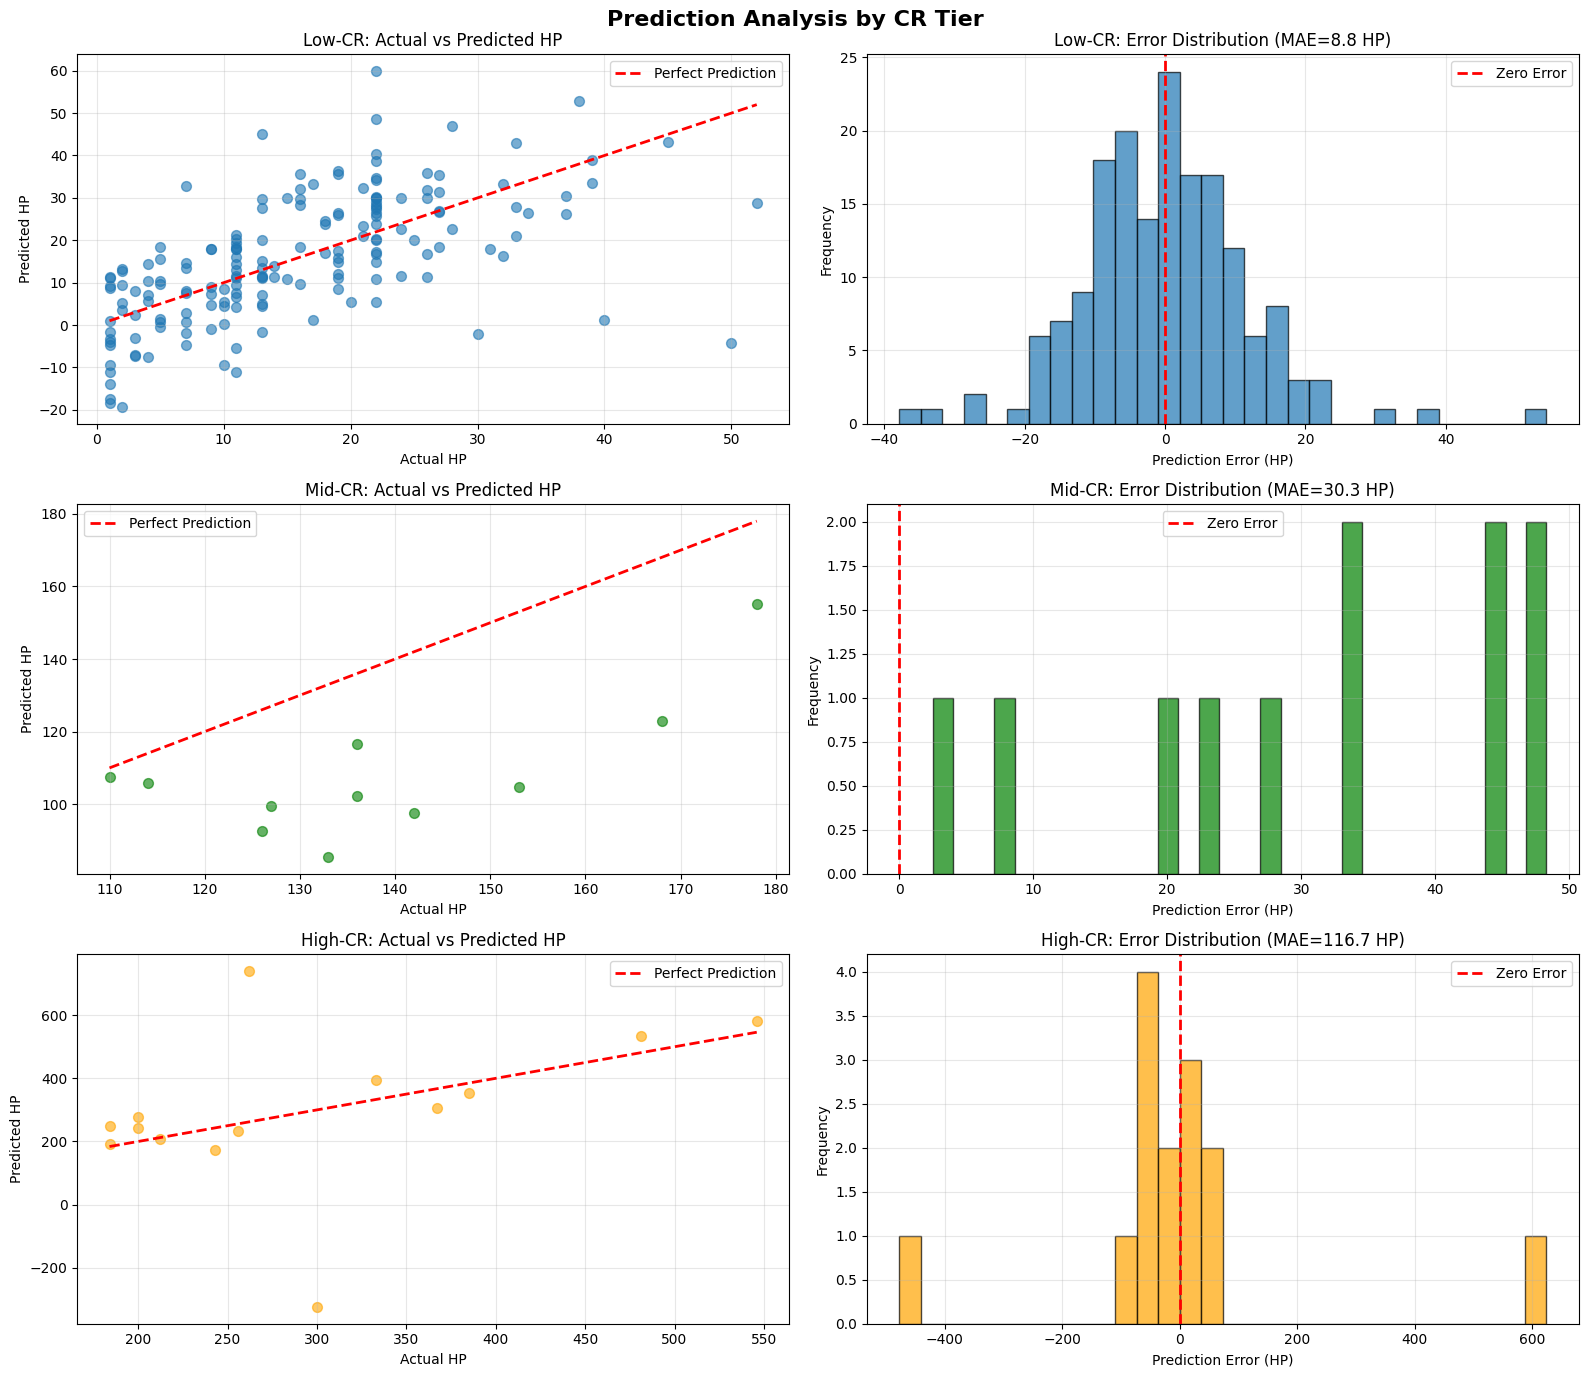


✅ Prediction analysis complete!


In [19]:
print("🔍 ANALYZING BEST AND WORST PREDICTIONS")
print("=" * 80)

def analyze_predictions(df_tier, y_actual, y_pred, tier_name):
    """Analyze and display best/worst predictions for a CR tier."""
    
    # Calculate errors
    errors = y_actual - y_pred
    abs_errors = np.abs(errors)
    pct_errors = (errors / y_actual) * 100
    
    # Create analysis dataframe
    analysis = pd.DataFrame({
        'Name': df_tier['Name'].values,
        'Type': df_tier['Type'].values,
        'CR': df_tier['cr_numeric'].values,
        'Actual_HP': y_actual,
        'Predicted_HP': y_pred,
        'Error': errors,
        'Abs_Error': abs_errors,
        'Pct_Error': pct_errors
    })
    
    # Sort by absolute error
    analysis = analysis.sort_values('Abs_Error')
    
    # Get best and worst 10
    best_10 = analysis.head(10)
    worst_10 = analysis.tail(10).sort_values('Abs_Error', ascending=False)
    
    print(f"\n{'='*80}")
    print(f"{tier_name}")
    print(f"{'='*80}")
    
    print(f"\n✅ TOP 10 MOST ACCURATE PREDICTIONS:")
    print(f"{'Name':<30} {'Type':<15} {'CR':>5} {'Actual':>7} {'Pred':>7} {'Error':>7} {'%Err':>7}")
    print("-" * 84)
    for idx, row in best_10.iterrows():
        print(f"{row['Name']:<30} {row['Type']:<15} {row['CR']:>5.1f} "
              f"{row['Actual_HP']:>7.0f} {row['Predicted_HP']:>7.0f} "
              f"{row['Error']:>7.0f} {row['Pct_Error']:>6.1f}%")
    
    print(f"\n❌ TOP 10 LEAST ACCURATE PREDICTIONS:")
    print(f"{'Name':<30} {'Type':<15} {'CR':>5} {'Actual':>7} {'Pred':>7} {'Error':>7} {'%Err':>7}")
    print("-" * 84)
    for idx, row in worst_10.iterrows():
        print(f"{row['Name']:<30} {row['Type']:<15} {row['CR']:>5.1f} "
              f"{row['Actual_HP']:>7.0f} {row['Predicted_HP']:>7.0f} "
              f"{row['Error']:>7.0f} {row['Pct_Error']:>6.1f}%")
    
    # Summary statistics
    print(f"\n📊 Summary Statistics:")
    print(f"   Mean Absolute Error: {abs_errors.mean():.2f} HP")
    print(f"   Median Absolute Error: {np.median(abs_errors):.2f} HP")
    print(f"   Max Absolute Error: {abs_errors.max():.2f} HP")
    print(f"   Mean Percentage Error: {np.abs(pct_errors).mean():.1f}%")
    
    return analysis

# Analyze each tier using the correct dataframes and predictions
analysis_low = analyze_predictions(
    df_low_cr.loc[X_test_low.index], 
    df_low_cr.loc[X_test_low.index, 'actual_hp'].values, 
    y_pred_test_low, 
    "LOW-CR MODEL (CR ≤ 1)"
)

analysis_mid = analyze_predictions(
    df_mid_cr.loc[X_test_mid.index], 
    df_mid_cr.loc[X_test_mid.index, 'actual_hp'].values, 
    y_pred_test_mid, 
    "MID-CR MODEL (1 < CR ≤ 12)"
)

analysis_high = analyze_predictions(
    df_high_cr.loc[X_test_high.index], 
    df_high_cr.loc[X_test_high.index, 'actual_hp'].values, 
    y_pred_test_high, 
    "HIGH-CR MODEL (CR > 12)"
)

# Create visualizations
print("\n" + "=" * 80)
print("Creating visualizations...")
print("=" * 80)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Prediction Analysis by CR Tier', fontsize=16, fontweight='bold')

# Low-CR visualizations
if len(analysis_low) > 0:
    # Scatter plot: Actual vs Predicted
    axes[0, 0].scatter(analysis_low['Actual_HP'], analysis_low['Predicted_HP'], alpha=0.6, s=50)
    axes[0, 0].plot([analysis_low['Actual_HP'].min(), analysis_low['Actual_HP'].max()],
                     [analysis_low['Actual_HP'].min(), analysis_low['Actual_HP'].max()],
                     'r--', linewidth=2, label='Perfect Prediction')
    axes[0, 0].set_xlabel('Actual HP')
    axes[0, 0].set_ylabel('Predicted HP')
    axes[0, 0].set_title('Low-CR: Actual vs Predicted HP')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Error distribution
    axes[0, 1].hist(analysis_low['Error'], bins=30, alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[0, 1].set_xlabel('Prediction Error (HP)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'Low-CR: Error Distribution (MAE={analysis_low["Abs_Error"].mean():.1f} HP)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# Mid-CR visualizations
if len(analysis_mid) > 0:
    # Scatter plot: Actual vs Predicted
    axes[1, 0].scatter(analysis_mid['Actual_HP'], analysis_mid['Predicted_HP'], alpha=0.6, s=50, color='green')
    axes[1, 0].plot([analysis_mid['Actual_HP'].min(), analysis_mid['Actual_HP'].max()],
                     [analysis_mid['Actual_HP'].min(), analysis_mid['Actual_HP'].max()],
                     'r--', linewidth=2, label='Perfect Prediction')
    axes[1, 0].set_xlabel('Actual HP')
    axes[1, 0].set_ylabel('Predicted HP')
    axes[1, 0].set_title('Mid-CR: Actual vs Predicted HP')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Error distribution
    axes[1, 1].hist(analysis_mid['Error'], bins=30, alpha=0.7, edgecolor='black', color='green')
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[1, 1].set_xlabel('Prediction Error (HP)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'Mid-CR: Error Distribution (MAE={analysis_mid["Abs_Error"].mean():.1f} HP)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

# High-CR visualizations
if len(analysis_high) > 0:
    # Scatter plot: Actual vs Predicted
    axes[2, 0].scatter(analysis_high['Actual_HP'], analysis_high['Predicted_HP'], alpha=0.6, s=50, color='orange')
    axes[2, 0].plot([analysis_high['Actual_HP'].min(), analysis_high['Actual_HP'].max()],
                     [analysis_high['Actual_HP'].min(), analysis_high['Actual_HP'].max()],
                     'r--', linewidth=2, label='Perfect Prediction')
    axes[2, 0].set_xlabel('Actual HP')
    axes[2, 0].set_ylabel('Predicted HP')
    axes[2, 0].set_title('High-CR: Actual vs Predicted HP')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    # Error distribution
    axes[2, 1].hist(analysis_high['Error'], bins=30, alpha=0.7, edgecolor='black', color='orange')
    axes[2, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[2, 1].set_xlabel('Prediction Error (HP)')
    axes[2, 1].set_ylabel('Frequency')
    axes[2, 1].set_title(f'High-CR: Error Distribution (MAE={analysis_high["Abs_Error"].mean():.1f} HP)')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✅ Prediction analysis complete!")
print("=" * 80)

## Prediction Analysis: Best and Worst Performers

In [20]:
print("\n📊 EXPORTING ENGINEERED FEATURES TO CSV")
print("=" * 80)

# Combine all three CR tiers back into one dataframe
export_df = pd.concat([df_low_cr, df_mid_cr, df_high_cr], ignore_index=False)

# Select columns to export
columns_to_export = [
    # Identifying information
    'Name', 'Type', 'Size', 'Challenge_Rating', 'cr_numeric',
    
    # Original stats
    'HP', 'actual_hp', 'AC', 'ac_value',
    
    # Baselines
    'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline', 'dc_baseline',
    
    # Combat stats
    'highest_attack_bonus', 'highest_save_dc', 'estimated_dpr',
    
    # Phase 2: Deviations
    'ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation',
    
    # Phase 2: Result
    'hp_after_phase2', 'residual_hp',
    
    # Phase 3: Scaled features
    'has_flying_scaled', 'has_legendary_resistance_scaled', 
    'has_magic_resistance_scaled', 'has_regeneration_scaled', 
    'has_legendary_actions_scaled',
    
    # Phase 3: Movement
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'max_speed', 'movement_types_count', 'has_flying',
    
    # Phase 3: Defenses
    'save_proficiency_count', 'skill_proficiency_count',
    'resistance_count', 'immunity_count', 'vulnerability_count', 
    'condition_immunity_count',
    
    # Phase 3: Senses
    'has_darkvision', 'darkvision_range', 'has_blindsight', 
    'has_truesight', 'has_tremorsense', 'passive_perception',
    
    # Phase 3: Abilities
    'trait_count', 'action_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    'total_ability_count',
    
    # Phase 3: Special abilities
    'has_legendary_actions', 'has_legendary_resistance', 
    'has_magic_resistance', 'has_regeneration',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal', 'has_grapple',
    
    # Phase 3: Condition infliction
    'inflicts_poisoned', 'inflicts_blinded', 'inflicts_charmed',
    'inflicts_deafened', 'inflicts_frightened', 'inflicts_incapacitated',
    'inflicts_paralyzed', 'inflicts_petrified', 'inflicts_prone',
    'inflicts_restrained', 'inflicts_stunned'
]

# Filter to only columns that exist in the dataframe
existing_columns = [col for col in columns_to_export if col in export_df.columns]
export_data = export_df[existing_columns].copy()

# Sort by CR for easier inspection
export_data = export_data.sort_values('cr_numeric')

# Export to CSV
output_path = '../data/engineered_features.csv'
export_data.to_csv(output_path, index=False)

print(f"✅ Exported {len(export_data)} monsters with {len(existing_columns)} features")
print(f"✅ Saved to: {output_path}")

print("\n📋 Exported Columns:")
print(f"   - Identification: Name, Type, Size, CR")
print(f"   - Original Stats: HP, AC, Attack, DPR, Save DC")
print(f"   - Baselines: hp_baseline, ac_baseline, etc.")
print(f"   - Phase 2: Deviations and hp_after_phase2")
print(f"   - Phase 3: All {len(phase3_features)} engineered features")

print(f"\n🔍 Sample of exported data:")
display(export_data[['Name', 'cr_numeric', 'actual_hp', 'hp_baseline', 
                      'hp_after_phase2', 'residual_hp']].head(10))


📊 EXPORTING ENGINEERED FEATURES TO CSV
✅ Exported 382 monsters with 72 features
✅ Saved to: ../data/engineered_features.csv

📋 Exported Columns:
   - Identification: Name, Type, Size, CR
   - Original Stats: HP, AC, Attack, DPR, Save DC
   - Baselines: hp_baseline, ac_baseline, etc.
   - Phase 2: Deviations and hp_after_phase2
   - Phase 3: All 41 engineered features

🔍 Sample of exported data:


,Name,cr_numeric,actual_hp,hp_baseline,hp_after_phase2,residual_hp
27,Animated Object (Huge),0.0,40,4.5,-50.875,90.875
30,Animated Object (Tiny),0.0,10,4.5,-35.125,45.125
29,Animated Object (Small or Medium),0.0,10,4.5,-35.125,45.125
28,Animated Object (Large),0.0,20,4.5,-41.875,61.875
45,Badger,0.0,3,4.5,2.625,0.375
44,Baboon,0.0,3,4.5,-3.125,6.125
39,Awakened Shrub,0.0,10,4.5,5.875,4.125
38,Avatar of Death,0.0,1,4.5,-22.875,23.875
88,Crab,0.0,2,4.5,7.625,-5.625
112,Eagle,0.0,3,4.5,-21.625,24.625
